In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy.cluster.hierarchy import linkage, leaves_list, dendrogram

windows = True if os.name == 'nt' else False

if windows:
    workspace_path = "P:/workspaces/lg-ukbiobank/projects/"
else:
    workspace_path = "/data/workspaces/lag/workspaces/lg-ukbiobank/projects/"

colors = [ '#ED6B06',  "whitesmoke", '#00786A']
palette = LinearSegmentedColormap.from_list("custom_palette", colors)

labels_g1_lifg = "G1 LIFG IC1,G1 LIFG IC2,G1 LIFG IC3".split(",")
labels_g2_lifg = "G2 LIFG IC1,G2 LIFG IC2,G2 LIFG IC3".split(",")
labels_g1_lstg = "G1 LSTS IC1,G1 LSTS IC2,G1 LSTS IC3".split(",")
labels_g2_lstg = "G2 LSTS IC1,G2 LSTS IC2,G2 LSTS IC3".split(",")

labels_lifg = labels_g1_lifg + labels_g2_lifg
labels_lstg = labels_g1_lstg + labels_g2_lstg

labels = labels_g1_lifg + labels_g2_lifg + labels_g1_lstg + labels_g2_lstg

In [10]:
def get_cc_data(fn, idx_nms, col_nms):
    data = np.loadtxt(fn)[:, 2]
    data = data.reshape(6,6)
    df = pd.DataFrame(data, columns=col_nms, index=idx_nms)
    return df

def plot_correlation_with_clustering(corr_df, ):
    linkage_matrix = linkage(corr_df, method='average', metric='correlation')
    leaf_order = leaves_list(linkage_matrix)
    corr_df = corr_df.iloc[leaf_order, :].iloc[:, leaf_order]

    # Create figure with subplots for dendrogram and heatmap
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9), gridspec_kw={'height_ratios': [1, 10]})
    dendro = dendrogram(linkage_matrix, labels=corr_df.index, leaf_rotation=90, ax=ax1)
    #ax1.set_title("Spatial Correlations between PMAP Components", fontsize=14, fontweight='bold')
    ax1.set_ylabel("")
    #make ticks invisble
    ax1.set_xticks([])
    ax1.set_yticks([])
    ax1.spines['top'].set_visible(False)      # Remove top border
    ax1.spines['right'].set_visible(False)    # Remove right border
    ax1.spines['bottom'].set_visible(False)   # Remove bottom border
    ax1.spines['left'].set_visible(False)      # Remove left border

    # remove white space between dendrogram and heatmap
    plt.subplots_adjust(hspace=-0.55)

    # Create heatmap subplot
    ax2 = plt.subplot(2, 1, 2)
    sns.heatmap(corr_df.astype(float), annot=True, fmt=".2f", cmap=palette, center=0, 
                cbar_kws={'label': 'Correlation Coefficient'}, ax=ax2, cbar=False,
                square=True, linewidths=0.5)

    ax2.set_xlabel("Components", fontsize=12)
    ax2.set_ylabel("Components", fontsize=12)
    ax2.set_xticklabels(corr_df.index, rotation=45, size=10, ha='right')
    ax2.set_yticklabels(corr_df.columns, rotation=0, size=10, ha='right')
    ax2.tick_params(axis='both', which='both', length=0)
    
    plt.tight_layout()


            G1 LIFG IC1 G1 LIFG IC2 G1 LIFG IC3 G2 LIFG IC1 G2 LIFG IC2  \
G1 LIFG IC1         1.0         0.0         0.0    -0.30624     0.69819   
G1 LIFG IC2         0.0         1.0         0.0    -0.27562    -0.09257   
G1 LIFG IC3         0.0         0.0         1.0     0.81801    -0.06248   
G2 LIFG IC1    -0.30624    -0.27562     0.81801         1.0        -0.0   
G2 LIFG IC2     0.69819    -0.09257    -0.06248        -0.0         1.0   
G2 LIFG IC3     -0.1915      0.8946     0.04812        -0.0        -0.0   
G1 LSTS IC1         NaN         NaN         NaN         NaN         NaN   
G1 LSTS IC2         NaN         NaN         NaN         NaN         NaN   
G1 LSTS IC3         NaN         NaN         NaN         NaN         NaN   
G2 LSTS IC1         NaN         NaN         NaN         NaN         NaN   
G2 LSTS IC2         NaN         NaN         NaN         NaN         NaN   
G2 LSTS IC3         NaN         NaN         NaN         NaN         NaN   

            G2 LIFG IC3 

C:\Users\jitame\AppData\Local\Temp\ipykernel_13128\160003562.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  plot_correlation_with_clustering(all_df.fillna(0))


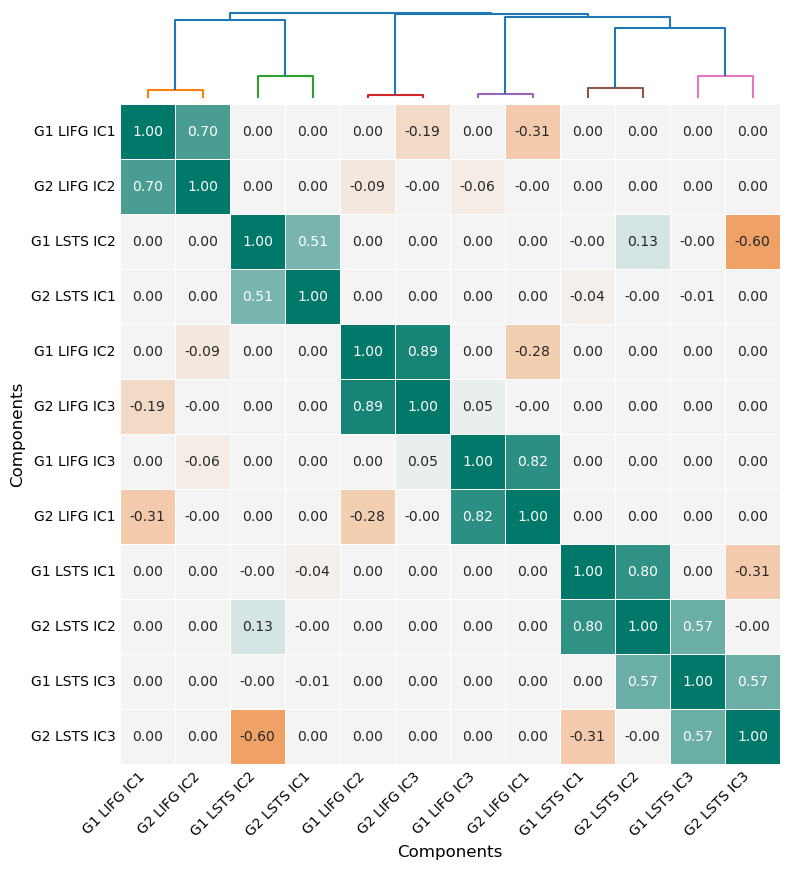

In [12]:
# read spatial correlations from FSLCC
g1_df = get_cc_data(os.path.join(workspace_path, "CONGRADS_rest", "fslcc_lifg_cmap_all.txt"), labels_lifg, labels_lifg)
g2_df = get_cc_data(os.path.join(workspace_path, "CONGRADS_rest", "fslcc_lstg_cmap_all.txt"), labels_lstg, labels_lstg)

all_df = pd.DataFrame(columns=labels, index=labels)

for i in all_df.index:
    for j in all_df.columns:
        if i in g1_df.index and j in g1_df.columns:
            all_df.loc[i, j] = g1_df.loc[i, j]
            all_df.loc[j, i] = g1_df.loc[i, j]
        elif i in g2_df.index and j in g2_df.columns:
            all_df.loc[i, j] = g2_df.loc[i, j]
            all_df.loc[j, i] = g2_df.loc[i, j]
        else:
            all_df.loc[i, j] = np.nan

print(all_df)
plot_correlation_with_clustering(all_df.fillna(0))

plt.savefig(os.path.join(workspace_path, "CONGRADS_rest", "spatial_correlations_clustering_cmap.png"), dpi=300)

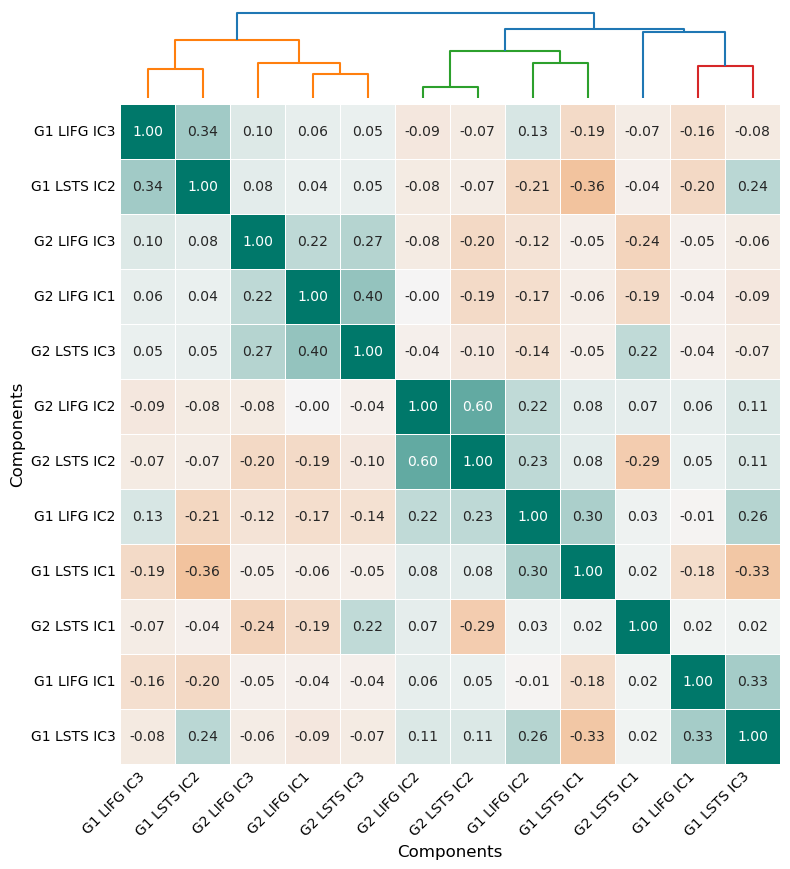

In [13]:
#generate subject loading correlations fromp IDPs
data = pd.read_csv(os.path.join(workspace_path, "CONGRADS_rest", "all_idps_congrads_new_resid_N46267.tsv") , sep="\t")
cols = ["melodic_g1_cmap_lifg_oic_0", "melodic_g1_cmap_lifg_oic_1", "melodic_g1_cmap_lifg_oic_2", "melodic_g1_cmap_lstg_oic_0", "melodic_g1_cmap_lstg_oic_1", "melodic_g1_cmap_lstg_oic_2", "melodic_g2_cmap_lifg_oic_0", "melodic_g2_cmap_lifg_oic_1", "melodic_g2_cmap_lifg_oic_2", "melodic_g2_cmap_lstg_oic_0", "melodic_g2_cmap_lstg_oic_1", "melodic_g2_cmap_lstg_oic_2"]
data = data[cols]
subj_corrs = data.corr()

subj_corrs.columns = labels
subj_corrs.index = labels

plot_correlation_with_clustering(subj_corrs.fillna(0))

plt.savefig(os.path.join(workspace_path, "CONGRADS_rest", "subject_correlations_clustering_cmap.png"), dpi=300)


C:\Users\jitame\AppData\Local\Temp\ipykernel_13128\510383011.py:21: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=True, color='white', linewidth=2, edgecolor='black'))


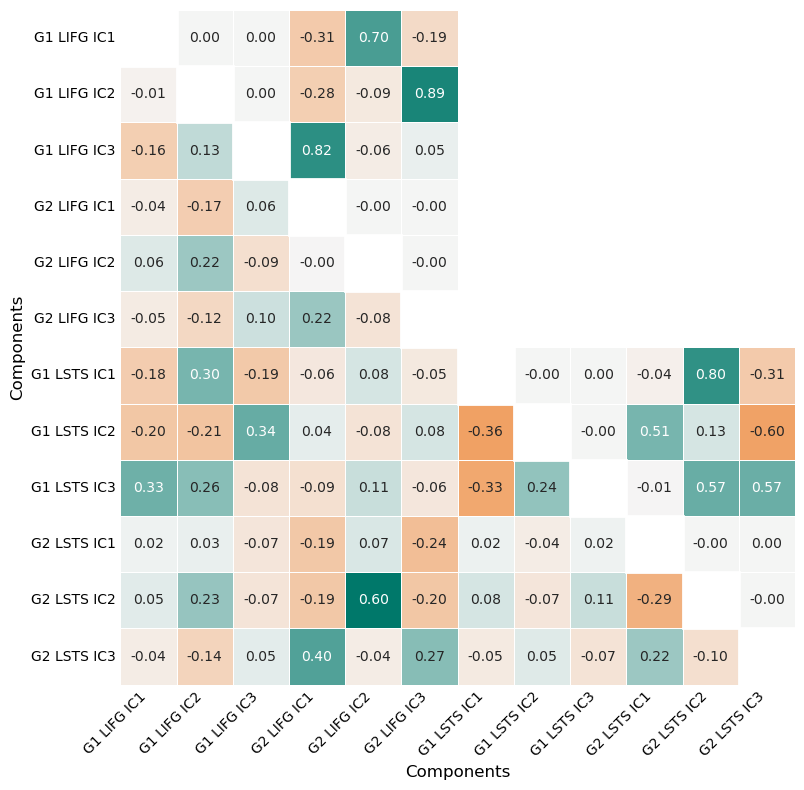

In [18]:
# generate correlation plot with upper triangle spatial correlations and lower triangle subject loadings correlations
fig, ax = plt.subplots(figsize=(10,8))
#mask to get upper triangle
mask_upper = np.triu(np.ones_like(all_df, dtype=bool), k=1)  # Changed k=0 to k=1 to exclude diagonal
#mask to get lower triangle
mask_lower = np.tril(np.ones_like(subj_corrs, dtype=bool), k=-1)  # Changed k=0 to k=-1 to exclude diagonal

# Plot upper triangle with spatial correlations
sns.heatmap(all_df.astype(float), annot=True, fmt=".2f", cmap=palette, center=0, 
            cbar_kws={'label': 'Spatial Correlation Coefficient'}, ax=ax, vmin=-1., mask=~mask_upper,
            square=True, linewidths=0.5, cbar=False)

# Plot lower triangle with subject correlations
sns.heatmap(subj_corrs.astype(float), annot=True, fmt=".2f", cmap=palette, center=0, 
            ax=ax, mask=~mask_lower, cbar=False, square=True, linewidths=0.5)

#make boundaries of the upper triangle mask bold

# Create wider diagonal separation by adding white rectangles with thicker borders
for i in range(len(all_df)):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=True, color='white', linewidth=2, edgecolor='black'))

ax.set_xlabel("Components", fontsize=12)
ax.set_ylabel("Components", fontsize=12)
ax.set_xticklabels(all_df.index, rotation=45, size=10, ha='right')
ax.set_yticklabels(all_df.columns, rotation=0, size=10, ha='right')
ax.tick_params(axis='both', which='both', length=0)
plt.tight_layout()

plt.savefig(os.path.join(workspace_path, "CONGRADS_rest", "spatial_subject_correlation_matrix_cmap.png"), dpi=300)
